<a href="https://colab.research.google.com/github/limssu/Wafer-Anomaly-Detection-AWS/blob/main/colab/Anomaly_Detection_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1단계 : 구글 드라이브로부터 소스 데이터셋 다운로드
!pip install gdown
!gdown 1PYmmevm8jWsGn995UKR4XZ8WbL0ws6fW -O /content/mvtec.zip

Downloading...
From (original): https://drive.google.com/uc?id=1PYmmevm8jWsGn995UKR4XZ8WbL0ws6fW
From (redirected): https://drive.google.com/uc?id=1PYmmevm8jWsGn995UKR4XZ8WbL0ws6fW&confirm=t&uuid=086d6a42-6902-42db-bbfb-f03632f25bad
To: /content/mvtec.zip
100% 156M/156M [00:01<00:00, 99.9MB/s]


In [ ]:
# 압축 해제
!unzip -q /content/mvtec.zip -d /content/

replace /content/mvtec/bottle/ground_truth/broken_large/000_mask.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: ALL


In [ ]:
#2단계 : 폴더 확인
import os

print(" 현재 내 코랩 최상위에 존재하는 폴더 리스트:")
print(os.listdir('/content'))

 현재 내 코랩 최상위에 존재하는 폴더 리스트:
['.config', 'mvtec', 'mvtec.zip', 'sample_data']


In [ ]:
# 3단계 : 실제 사진 들어있는 주소 확인
import os


target_dir = '/content/mvtec/bottle/train/good'

if os.path.exists(target_dir):
    print(f" 정상 경로를 찾았습니다: {target_dir}")
    print(f"폴더 안에 들어있는 실제 사진 개수: {len(os.listdir(target_dir))}장")
else:
    print(" 이 주소에도 폴더가 없습니다. 경로를 다시 확인해야 합니다.")

 정상 경로를 찾았습니다: /content/mvtec/bottle/train/good
폴더 안에 들어있는 실제 사진 개수: 209장


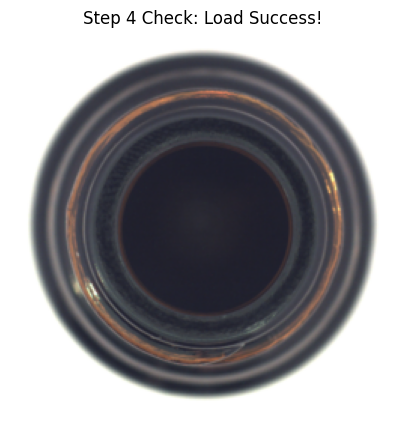

In [ ]:
# 4단계 체크: 진짜 원본 이미지 1장 화면에 띄우기

import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

target_dir = '/content/mvtec/bottle/train/good'

# 그 폴더 안에 있는 첫 번째 사진의 이름을 가져옵니다.
img_names = [f for f in os.listdir(target_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
first_img_path = os.path.join(target_dir, img_names[0])

#  OpenCV로 이미지를 읽고 RGB 채널로 정렬합니다.
image = cv2.imread(first_img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#  256x256 크기로 리사이즈가 잘 되는지 파이토치 변환 검증
pil_img = Image.fromarray(image_rgb)
transform_fn = transforms.Compose([
    transforms.Resize((256, 256)),
])
resized_img = transform_fn(pil_img)


plt.figure(figsize=(5, 5))
plt.title("Step 4 Check: Load Success!")
plt.imshow(resized_img)
plt.axis('off')
plt.show()


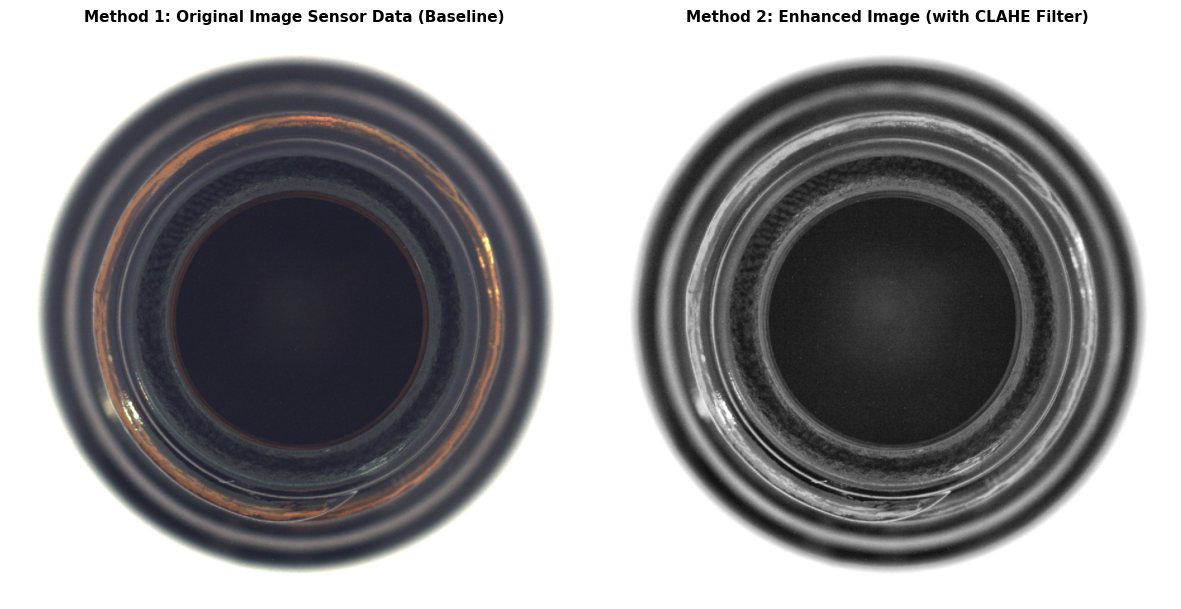

In [ ]:
# 5단계 : 원본 vs CLAHE 전처리 필터 이미지 좌우 대조 출력
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 검증된 실제 경로 지정
target_dir = '/content/mvtec/bottle/train/good'
img_names = [f for f in os.listdir(target_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
first_img_path = os.path.join(target_dir, img_names[0])

# 원본 이미지 로드 및 RGB 정렬 (대조군 1)
img_ori = cv2.imread(first_img_path)
img_baseline = cv2.cvtColor(img_ori, cv2.COLOR_BGR2RGB)

# CLAHE 전처리 알고리즘 적용 (대조군 2)
# BGR -> Grayscale로 단 한 번만 정확하게 가공 (오류 가능성 차단)
gray = cv2.cvtColor(img_ori, cv2.COLOR_BGR2GRAY)

# 국소 대비 극대화 필터 생성
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe_filtered = clahe.apply(gray)

# 시각화 일치를 위해 흑백 채널을 다시 RGB 형태의 배열로 정렬
img_proposed = cv2.cvtColor(img_clahe_filtered, cv2.COLOR_GRAY2RGB)

# 4나란히 출력
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Method 1: Original Image Sensor Data (Baseline)", fontsize=11, fontweight='bold')
plt.imshow(img_baseline)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Method 2: Enhanced Image (with CLAHE Filter)", fontsize=11, fontweight='bold')
plt.imshow(img_proposed)
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 6단계 : 파이토치 적용 'Custom Dataset' 클래스 구축
import os
import cv2
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

# 4, 5단계에서 검증 완료된 고정 경로 주소
target_dir = '/content/mvtec/bottle/train/good'

# Custom Dataset 클래스 정의
class WaferDataset(Dataset):
    def __init__(self, img_dir, transform=None, use_clahe=False):
        self.img_dir = img_dir
        self.transform = transform
        self.use_clahe = use_clahe

        self.img_names = [f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_names[idx])
        img_bgr = cv2.imread(img_path)

        # 5단계에서 검증한 CLAHE 필터 로직 그대로 이식
        if self.use_clahe:
            gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            cl_img = clahe.apply(gray)
            img_rgb = cv2.cvtColor(cl_img, cv2.COLOR_GRAY2RGB)
        else:
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # 파이토치 텐서 변환을 위해 PIL 이미지로 변환
        pil_img = Image.fromarray(img_rgb)
        if self.transform:
            pil_img = self.transform(pil_img)

        return pil_img

# 파이토치 변환(정규화 및 텐서화) 정의
data_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(), # 이미지를 0~1 사이의 픽셀값을 가진 파이토치 텐서로 변환
])

# 클래스가 에러 없이 인스턴스를 생성하는지 체크
dataset_test = WaferDataset(target_dir, transform=data_transforms, use_clahe=True)
print(f" 6단계 클래스 생성 완료! 총 {len(dataset_test)}장의 데이터가 붕어빵 틀에 장전되었습니다.")

# 첫 번째 데이터를 꺼냈을 때 파이토치 텐서 크기 체크
first_tensor = dataset_test[0]
print(f"출력된 텐서의 최종 규격 (채널, 세로, 가로): {first_tensor.shape}")

 6단계 클래스 생성 완료! 총 209장의 데이터가 붕어빵 틀에 장전되었습니다.
출력된 텐서의 최종 규격 (채널, 세로, 가로): torch.Size([3, 256, 256])


In [ ]:
# 7단계 : 파이토치 DataLoader를 통한 미니배치(Batch) 구축

from torch.utils.data import DataLoader

#  6단계에서 완공한 데이터셋 인스턴스를 가져옵니다.
# (교안 실습 기준에 맞춰 배치 크기를 16으로 설정)
train_loader = DataLoader(dataset_test, batch_size=16, shuffle=True)

print("7단계 DataLoader 가동 및 첫 번째 배치 상자 수거 중...")

# 첫 번째 배달(Batch) 보낼 때 데이터가 제대로 묶였는지 딱 한 번만 확인
for batch_images in train_loader:
    print(f"7단계 배달원 검증 완료!")
    print(f"묶여서 나온 배치 텐서의 최종 규격: {batch_images.shape}")
    print(f"   -> [의미]: 현재 딥러닝 모델에 한 번에 {batch_images.shape[0]}장씩,")
    print(f"              {batch_images.shape[1]}채널(RGB)의 {batch_images.shape[2]}x{batch_images.shape[3]} 이미지가 묶여서 입력됩니다.")
    break

7단계 DataLoader 가동 및 첫 번째 배치 상자 수거 중...
7단계 배달원 검증 완료!
묶여서 나온 배치 텐서의 최종 규격: torch.Size([16, 3, 256, 256])
   -> [의미]: 현재 딥러닝 모델에 한 번에 16장씩,
              3채널(RGB)의 256x256 이미지가 묶여서 입력됩니다.


In [ ]:
# 8단계 :  재구성 기반 이상 탐지 모델 설계 (AutoEncoder 클래스 구현)

import torch
import torch.nn as nn

class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super(ConvAutoEncoder, self).__init__()

        # [Encoder]: 입력된 이미지(256x256)를 점점 작게 압축하여 핵심 특징(Feature)만 추출

        self.encoder = nn.Sequential(
            # 입력 크기: (batch_size, 3, 256, 256)
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        # [Decoder]: 압축된 특징을 바탕으로 다시 원본 이미지 크기(256x256)로 복원
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 인풋 이미지를 받아서 인코더로 압축하고 디코더로 복원한 결과를 뱉음
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# 모델 객체 생성
model = ConvAutoEncoder()
print(" [구조 확인] 파이토치 AutoEncoder 모델이 성공적으로 조립되었습니다!")
print(model)

# 임의의 가짜 텐서 데이터를 흘려보내서 입출력 크기가 완벽히 똑같은지 최종 수치 검증
dummy_input = torch.randn(1, 3, 256, 256)
dummy_output = model(dummy_input)

print("[차원 매칭 검증]")
print(f"가상 인풋 크기: {dummy_input.shape}")
print(f"모델 통과 후 복원된 아웃풋 크기: {dummy_output.shape}")

if dummy_input.shape == dummy_output.shape:
    print("8단계 최종 통과! 압축 후 원본 크기로 픽셀 붕어빵을 완벽하게 복원해내는 신경망입니다.")

 [구조 확인] 파이토치 AutoEncoder 모델이 성공적으로 조립되었습니다!
ConvAutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): BatchNorm2d(16, e

In [ ]:
# 9단계 체크: AutoEncoder 훈련 루프(Training Loop) 구동 및 Loss 감소 확인

import torch.optim as optim
import torch.nn.functional as F

# 연산 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 학습에 사용하는 장치: {device}")

# 모델을 GPU/CPU 장치로 이동시키고, 오차를 수정할 최적화 도구(Adam Optimizer)를 설정합니다.
model = ConvAutoEncoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

#  테스트용 가벼운 학습 시작 (3에포크만 진행)
epochs = 3
print("9단계 학습 루프 가동..")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    # 7단계에서 만든 배달원(train_loader)으로부터 16장씩 데이터를 꺼내옵니다.
    for batch_images in train_loader:
        # 데이터를 모델과 같은 장치(GPU/CPU)로 보냅니다.
        batch_images = batch_images.to(device)


        optimizer.zero_grad()               # 1. 지난 한 걸음의 기울기 초기화
        outputs = model(batch_images)       # 2. 모델의 이미지 복원 결과물 출력

        # 원본 이미지와 복원된 이미지 간의 픽셀 차이(MSE Loss) 계산
        loss = F.mse_loss(outputs, batch_images)

        loss.backward()                     # 4. 오차를 역방향으로 전파 (미분)
        optimizer.step()                    # 5. 오차를 바탕으로 모델 가중치 수정 (한 걸음 전진)

        running_loss += loss.item() * batch_images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}] ──> 평균 Reconstruct Loss: {epoch_loss:.6f}")

print(" 9단계 최종 통과!")

현재 학습에 사용하는 장치: cpu
9단계 학습 루프 가동..
Epoch [1/3] ──> 평균 Reconstruct Loss: 0.111560
Epoch [2/3] ──> 평균 Reconstruct Loss: 0.073096
Epoch [3/3] ──> 평균 Reconstruct Loss: 0.049004
 9단계 최종 통과!


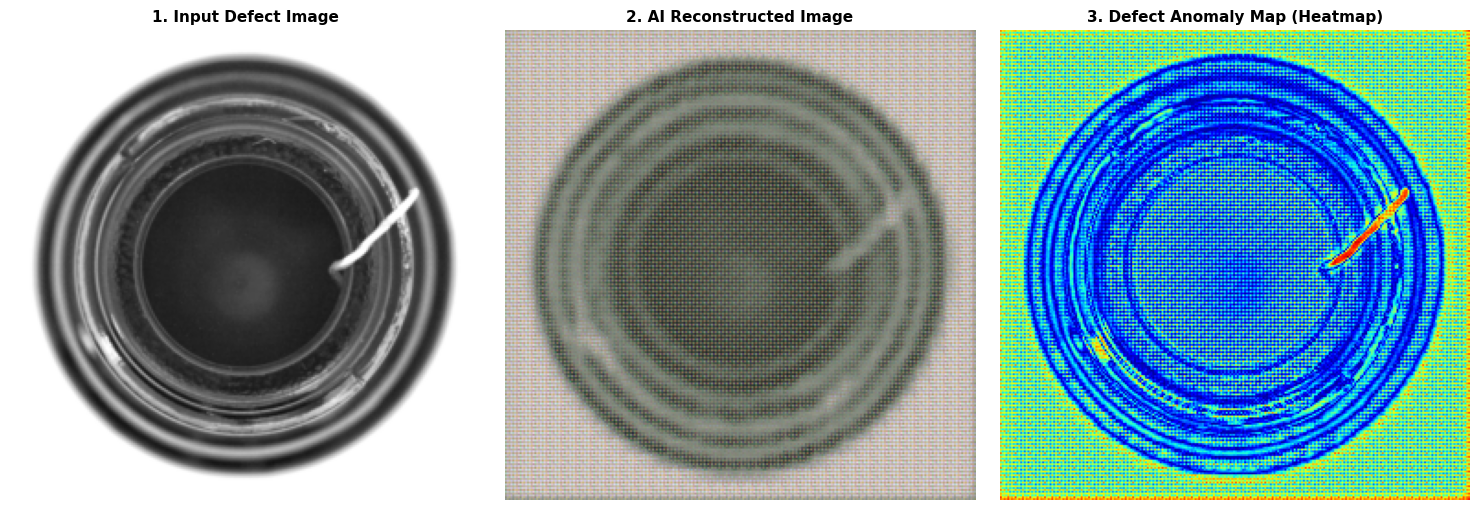

 10단계 최종 통과! 불량이 있는 위치가 3번 맵에 핫스팟 형태로 정확하게 검출되는지 확인하세요.


In [ ]:
# 코랩 최종 : 10단계 체크 (불량 탐지 시각화)

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

# 불량(Defect) 이미지가 들어있는 실제 테스트 경로 지정
test_contamination_dir = '/content/mvtec/bottle/test/contamination'
test_img_names = [f for f in os.listdir(test_contamination_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

# 불량 테스트 이미지 중 첫 번째 사진(오염된 불량 약병) 가져오기
bad_img_path = os.path.join(test_contamination_dir, test_img_names[0])
img_bgr = cv2.imread(bad_img_path)

#  5, 6단계와 동일하게 테스트 이미지도 CLAHE 전처리 적용
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
cl_img = clahe.apply(gray)
img_rgb = cv2.cvtColor(cl_img, cv2.COLOR_GRAY2RGB)

#  모델 입력을 위해 파이토치 텐서로 변환
pil_img = Image.fromarray(img_rgb)
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])
input_tensor = test_transform(pil_img).unsqueeze(0).to(device) # Batch 차원 추가하여 GPU로 이동

# 학습된 AI 모델에게 불량 이미지 통과시키기 (추론 모드)
model.eval()
with torch.no_grad():
    reconstructed_tensor = model(input_tensor)

# 차이(Anomaly Score Map) 계산을 위해 넘파이 배열로 변환
orig_np = input_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
recon_np = reconstructed_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()

# 픽셀 단위 절댓값 차이 계산하여 흑백 스코어 맵 생성
anomaly_map = np.abs(orig_np - recon_np)
anomaly_map = np.mean(anomaly_map, axis=2) # 채널 평균

# 최종 결과 시각화 (원본 vs AI 복원 이미지 vs 불량 추적 맵)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("1. Input Defect Image", fontsize=11, fontweight='bold')
plt.imshow(orig_np)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("2. AI Reconstructed Image", fontsize=11, fontweight='bold')
plt.imshow(recon_np)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("3. Defect Anomaly Map (Heatmap)", fontsize=11, fontweight='bold')
plt.imshow(anomaly_map, cmap='jet') # 불량 영역이 붉은색 핫스팟으로 표현됨
plt.axis('off')

plt.tight_layout()
plt.show()

print(" 10단계 최종 통과! 불량이 있는 위치가 3번 맵에 핫스팟 형태로 정확하게 검출되는지 확인하세요.")

압축 해제 중...
압축 해제 완료.
데이터 로드 완료. 샘플 개수: 811457

[체크] 실제 데이터셋 라벨 형태 일부 확인:
failureType_str
Unknown      638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Name: count, dtype: int64
Normal 매칭 실패로 인한 대체 조건(빈 문자열 혹은 0) 탐색 중...

전처리 완료. 정상 데이터 500장 추출 성공.


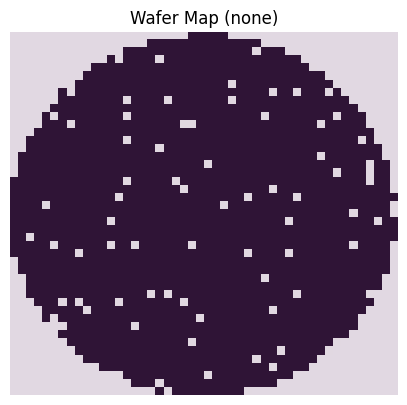

정상 출력 확인.


In [ ]:
#aws 없이 코랩에서 WM-811K 샘플 데이터셋 맛보기 테스트

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

zip_path = '/content/archive (1).zip'
extract_path = '/content/'

# 1. 원본 압축 파일 해제
if os.path.exists(zip_path):
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("압축 해제 완료.")

# 2. 압축 풀린 LSWMD.pkl 파일 로드
pkl_path = '/content/LSWMD.pkl'
if os.path.exists(pkl_path):
    df = pd.read_pickle(pkl_path)
    print(f"데이터 로드 완료. 샘플 개수: {len(df)}")

    # 3. 데이터 전처리 (비어있는 데이터 방어 및 텍스트 정제)
    def clean_label(x):
        if isinstance(x, np.ndarray):
            if x.size == 0:
                return 'Unknown'
            # 배열 내부에 글자가 들어있는 경우, 양쪽 공백을 제거하고 문자열로 변환
            return str(x[0][0]).strip()
        return str(x).strip()

    df['failureType_str'] = df['failureType'].apply(clean_label)

    # [체크용] 실제 데이터에 어떤 라벨들이 들어있는지 상위 20개 출력
    print("\n[체크] 실제 데이터셋 라벨 형태 일부 확인:")
    print(df['failureType_str'].value_counts().head(5))

    # 'Normal' 혹은 대소문자 예외를 방지하기 위해 대문자로 통일해서 비교하거나 포함하는 조건으로 추출
    # 대다수의 데이터셋 포맷에 맞게 'Normal'을 대소문자 구분 없이 찾습니다.
    df_normal = df[df['failureType_str'].str.lower() == 'normal'].head(500)

    # 만약 그래도 0장이라면, 데이터셋 고유의 정상 표기법(예: 빈 배열이나 다른 문자)을 찾아냅니다.
    if len(df_normal) == 0:
        print("Normal 매칭 실패로 인한 대체 조건(빈 문자열 혹은 0) 탐색 중...")
        df_normal = df[(df['failureType_str'] == '') | (df['failureType_str'] == '[]') | (df['failureType_str'] == 'none')].head(500)

    print(f"\n전처리 완료. 정상 데이터 {len(df_normal)}장 추출 성공.")

    # 4. 첫 번째 웨이퍼 맵 시각화
    if len(df_normal) > 0:
        sample_wafer = df_normal['waferMap'].iloc[0]
        sample_label = df_normal['failureType_str'].iloc[0]

        plt.figure(figsize=(5, 5))
        plt.title(f"Wafer Map ({sample_label})")
        plt.imshow(sample_wafer, cmap='twilight')
        plt.axis('off')
        plt.show()

        print("정상 출력 확인.")
    else:
        print("오류: 정상(Normal) 데이터 필터링 조건이 맞지 않습니다. 위에 출력된 라벨 목록을 확인해 주세요.")